# PERSIST Gene selection

**Aim:** Create a Gene list for spatial transcriptomics

The gene list is created in a three-step approach:

1. A list of manually curated genes and genes on interest.
2. Using the *supervised* PERSIST method with the cell annotation. This step is to include genes for more rare cell populations such as DCs etc that might be missed if only and unsupervised approach is used.
3. In a third step, we will increase the gene list using the *unsupervised* PERSIST method to select genes that are maximally predictive of the genome-wide expression profile.

A GPU is extremely helpful, as Pytorch runs a LOT faster with it.

In [1]:
import os
import sys
import scanpy as sc
import scipy
import numpy as np
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt
import torch
from persist import PERSIST, ExpressionDataset, HurdleLoss
import sklearn.model_selection
import session_info
import warnings
warnings.filterwarnings('ignore')


# Decrease this for testing, default 250
MAX_NEPOCHS = 250

/home/workspace/environment/sc-persist/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Import the reference dataset

The dataset will be uses to train the panel

* Paper: https://www.cell.com/cell/fulltext/S0092-8674(24)00058-8#sec-4-1
* Data: https://www.ebi.ac.uk/biostudies/arrayexpress/studies/E-MTAB-11491

In [2]:
base_dir = '/home/workspace/private/projects/kim'
panel_dir = os.path.join(base_dir, 'panel/csv/')
adata_path = os.path.join(base_dir, 'data/scrna-seq/h5ad/export_03/adata-scvi-labels.h5ad')

kim_path = os.path.join(panel_dir, 'new-genes/01_kim-lab-list.csv')
ref_path = os.path.join(panel_dir, 'new-genes/02_reference-marker-table.csv')

output_dir = os.path.join(panel_dir)

In [3]:
def import_uterus() -> sc.AnnData:
    """
    Import the Mouse Uterus reference dataset and perform some initial preprocessing steps.

    Returns:
        AnnData object representing the preprocessed mouse uterus Cell Reference dataset.
    """
    adata = sc.read_h5ad(adata_path)
    adata.layers['log1p'] = adata.X.copy()
    sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=10000, inplace=True)
    adata.obs['codes'] = pd.Categorical(adata.obs['cell_type']).codes
    adata.var["features"] = adata.var.index
    adata.var_names = adata.var["features"]
    return adata
adata = import_uterus()
adata

AnnData object with n_obs × n_vars = 2599 × 31053
    obs: 'sample_id', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribosomal', 'pct_counts_ribosomal', 'doublet_scores', 'predicted_doublets', 'batch', 'S_score', 'G2M_score', 'phase', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'cell_type', 'cell_class', 'Endothelial_cells_score', 'Natural_killer_cells_score', 'Fibroblasts_score', 'Mural_cells_score', 'Memory_T_cells_score', 'Invariant_natural_killer_cells_score', 'Mucosa_associated_T_cells_score', 'B_cells_score', 'Dendritic_cells_score', 'Macrophages_score', 'M1_macrophages_score', 'M2_macrophages_score', 'Columnar_epithelial_cells_score', 'Glandular_cells_score', 'Mast_cells_score', 'Ciliated_cells_score', 'codes'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'features'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_class_colors', 'cell_type_colors', 'leiden', 'leiden_scVI_1_colors', 'log

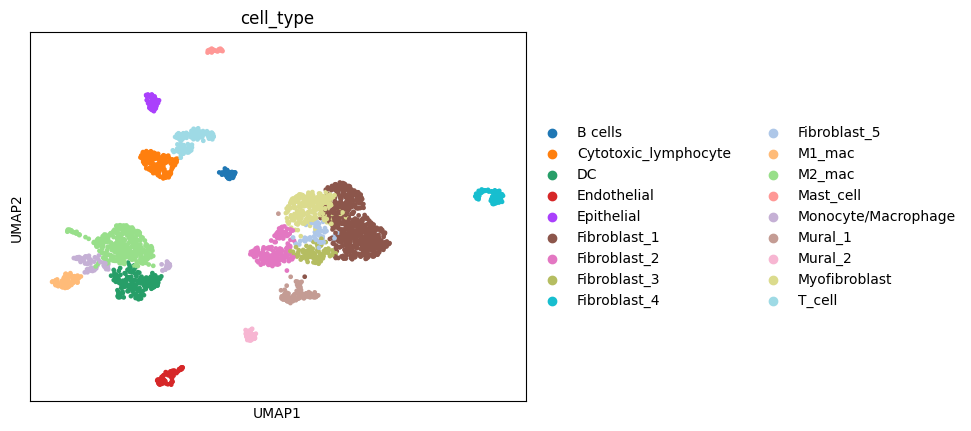

In [4]:
sc.pl.umap(adata, color="cell_type")

## Manual gene selection

These are the manually selected genes, that will be included in the final gene panel. PERSIST will choose the best genes to complement this manual selection.

### Helper functions

In [5]:
def all_genes_in_panel(panel: dict) -> list:
    """
    Returns a set of unique genes from the given panel.
    
    Args:
        panel (dict): A dictionary representing a genomic panel, where keys are sample names and values are lists of gene names for each sample.
    
    Returns:
        set: A set of unique genes found in the given panel.
    """
    return list(set(sum(panel.values(), [])))

def print_panel(panel: dict):
    """
    Prints information about the given panel, including the number of unique genes and a list of genes for each sample.
    
    Args:
        panel (dict): A dictionary representing a genomic panel, where keys are sample names and values are lists of gene names for each sample.
    
    Returns:
        None
    """
    class color:
        PURPLE = '\033[95m'
        CYAN = '\033[96m'
        DARKCYAN = '\033[36m'
        BLUE = '\033[94m'
        GREEN = '\033[92m'
        YELLOW = '\033[93m'
        RED = '\033[91m'
        BOLD = '\033[1m'
        UNDERLINE = '\033[4m'
        END = '\033[0m'

    print(color.UNDERLINE + color.BOLD + "Current Panel" + color.END)
    print(f"currently {color.PURPLE}{len(all_genes_in_panel(panel))}{color.END} unique genes")
    for k in panel.keys():
        import textwrap
        genes = ', '.join(panel[k])
        genes = '\n'.join(textwrap.wrap(genes, 128))
        print(color.BOLD + k + color.END + f" ({len(panel[k])} genes): " + genes)


### Gene lists

In [6]:
# Artis panel
artis_480 = pd.read_csv(os.path.join(panel_dir, "existing-panels/ID/TV46KD.csv")) #Artis panel
artis_480 = artis_480['Gene'].unique()
artis_480 = list(artis_480)
print("artis panel:", len(artis_480), "genes")

artis panel: 480 genes


In [7]:
# Kim lab gene list
kim_list = pd.read_csv(kim_path)
kim_list = kim_list['gene'].unique()
kim_list = list(kim_list)
print("Kim list length:", len(kim_list), "genes")

Kim list length: 24 genes


In [8]:
# Add genes to kim_list
kim_list = list(set(kim_list + [
    "Cma1", "Mcpt4", "Mrgprb1", "Apoe", "Cd81",
    "Tac1", "Calca", "Calcb", "Tacr1", "Ramp1",
    "Calcrl", "Adrb2", "Adrb3", "Mcpt1", "Mcpt2",
    "Mcpt9", "F2rl1", "Hdc", "Hrh1", "Htr2a",
    "Htr2b", "Htr2c", "Htr3a", "Htr3b", "Tnf",
    "Il6", "Alox5ap", "Lta4h", "Cysltr1", "Trpv1",
    "Scn10a"
]))

print("Kim list new length:", len(kim_list), "genes")

Kim list new length: 55 genes


In [9]:
# From cell paper
reference_list = [
    "Cldn5", "Tie1", "Vwf",
    "Klrb1c", "Nkg7", "Ccl5", "Cd7", "Eomes", "Cd86", "Ccl2", "Ccl7", "Ccl12", "Klrg1", "Cd27",
    "Col1a1", "Col1a2", "Col5a1", "Col6a1", "Loxl1", "Lum", "Fbln1", "Fbln2", "Pdgfra", "Dcn",
    "Acta2", "Des", "Mcam", "Tagln", "Notch3", "Rgs5", "Actg2", "Mustn1", "Myh11", "Rergl",
    "Cd69", "P2rx7", "Zfp683", "Gzmb", "Ccl4", "Il2ra", "Il7r", "Il2rb", "Cd44", "Il17a",
    "Cxcr3", "Itga1", "Ccl5", "Cd4", "Klrg1", "Nkg7",
    "Trav1", "Itgb3", "Cxcr6", "Cxcr3", "Il1r1", "Il12rb1", "Il18r1", "Il23r",
    "Cd19", "Ms4a1", "Cd79a", "Cd79b",
    "Itgax", "H2-Ab1", "H2-Eb1", "H2-Aa", "Adgre1", "Cx3cr1", "Il6", "Il10", "Il23a", "Adgre1", "Cd207", "Csf1r", "Il13", "Il5", "Il12a",
    "Cd14", "Cd163", "Cd86", "Cd209", "Csf1r", "Csf1r", "Il1b",
    "Tnf", "Il6", "Cd80", "Il12a", "Il23a", "Pfkfb3", "Acod1", "S100a9",
    "Il4", "Il13", "Tgfb1", "Arg1", "Pdcd1lg2", "Il10", "Mrc1", "Cd36", "Cd163", "Arg1", "Shpk",
    "Epcam", "Krt8", "Krt7", "Krt16", "Krt18", "Krt19", "Sprr2f", "Prap1", "Spink12",
    "Ltf", "Msx1", "Fam213a", "Krt19", "Cldn7", "Lif", "Foxa2", "Krt8", "Epcam",
    "Il5", "Ccl3", "Il13", "Il4",
    "Tuba1a", "Tuba1b", "Tubb4a", "Foxj1", "Capsl"
]

ref_list = list(set(reference_list))

print("Reference list length:", len(reference_list), "genes")

Reference list length: 130 genes


#### Remove genes from the artis-480 panel

Genes with low RF feature importance or low gene detection rates

In [10]:
# This was from round 1 of gene exclusion
genes_to_remove = [
    "Lamb1", "Ccl21a", "Thsd4", "Col15a1", "Prex2", "Lama2", "Pcsk5", "Cxcr5", "Lamc2", "Tmem100",
    "Fmo1", "Pdzrn3", "Crlf2", "Fbln5", "Prox1", "Tnc", "Flt3", "Foxp2", "Prkg1", "Jam3",
    "Itga3", "Hpgds", "Vta1", "Sox9", "Itgb7", "Adamdec1", "Aldh1a1", "Irf4", "Fcgr4", "Flt3l",
    "Fcer1a", "Zdhhc14", "Plcb1", "Itga2", "Homer2", "Adgrg2", "Mgl2", "Spib", "Itga11", "Sntb1",
    "Rep15", "Jam2", "Ifnlr1", "Tlsp", "Mest", "Areg", "Nt5e", "Smco4", "Dll4", "Cxcl13",
    "Sftpd", "Ppp1r14c", "Kcnma1", "Lama3", "Limch1", "Itga10", "Cst7", "Tac1", "Mctp1", "Il2",
    "Gli1", "Cyp4b1", "Pomc", "Dll1", "Slc1a3", "Ankrd37", "Tnfrsf4", "Cd226", "Upp1", "Chn2",
    "Ret", "Siglecf", "Itgb6", "Calca", "Adam23", "Slc2a2", "Ccr9", "Lama1", "Cd40lg", "Muc2",
    "Olfm4", "Rtkn2", "Nmu", "Lgr5", "Ccr4", "Cenpp", "Cd70", "Icam5", "Ncr1", "Calcb",
    "Rcn3", "Lamc3", "Notch4", "Tacr1", "Avil", "Itgad", "Itgb4", "Tcrg-C2", "Vipr1", "Slc34a2",
    "Gpihbp1", "Tcrg-C4", "Il9", "Dll3", "Clec1b", "Chgb", "Vtn", "Sucnr1", "Krt5", "Chga",
    "Slc9a3", "Neurog3", "Pou2f3", "Foxl1", "Nefl", "Il17f", "Guca2a", "Itln1", "Nmur1", "Nlrp9b",
    "Igf2", "Trpm5", "Spdef", "Ffar2", "Pyy", "Cyp2c55", "Adam2", "Fabp2", "Cd160", "Clca4a",
    "Cck", "Saa1", "Scgb3a2", "Taco1", "Atoh1", "Ptprn2", "Fer1l6", "Muc5ac", "Gfi1b", "Il22",
    "Habp2", "Ccl20", "Ccl19", "Il9r", "S100b", "Vip", "Adm2", "Il21", "Ccn1", "Ccn2",
    "Dlc1", "Arl6ip1", "Anp32b", "Pdpn", "Lrig1", "Meg3", "Rbms3", "Fcgbp", "Tcf21", "Pten",
    "Hs3st1", "Itga4", "Car2", "Rspo1", "Itga9", "Gdnf", "Itgb3", "Ldlr", "Pclaf", "Hepacam2",
    "Ccr6", "Cdca8", "Prom1", "Il12a", "Reln", "Ly6a", "Notch3", "St3gal6", "Dusp18", "Adam15",
    "Lyz1", "Itga7", "Hmgcr", "Itgb2", "Cebpa", "Fzd7", "Pdcd1lg2", "Nmb", "Hic1", "Itga2b",
    "Calr", "Madcam1", "Ly6g", "Itga1", "Hes1", "Itga8", "Hes1", "Ccl25", "Crip1", "Tmem176b",
    "Psma7"
]

In [11]:
# this was from round 2 of gene exclusion
genes_to_remove_2 = [
    "Hebp1", "H2-DMb2", "Adam17", "Cnn2", "Atp1b1", "Gna13", "S100a10", "Igfbp7",
    "Fstl1", "Col4a1", "Fcgr1", "Rbms1", "Vps37b", "Lgals1", "Hspa1b", "Cd24a",
    "Ebf1", "Anp32a", "Igfbp4", "Dpp4", "Col18a1", "S100a4", "Dusp10", "Dock10",
    "E2f1", "Ms4a4b", "Txnip", "Col3a1", "Notch2", "Cdc20"
]

In [12]:
# round 3 of gene exclusion
genes_to_remove_3 = [
    "Selenop", "Hspa1b", "Btg1", "Mxd1", "Rasl11b", "S100a4", "Ifitm2", "Mt1",
    "Timp3", "Rgs2", "Inpp4b", "Axin2", "Knl1", "F11r", "Notch1", "Anxa2",
    "E2f1", "Ebf1", "Scin",  "Pcna",  "Prss23",
     "Cd81", "Itgb8", "Cd34"
]

#"Robo2", "Srebf2", "Cdh1", "Cd83", "Ly6c2"

In [13]:
# make sure all the genes from artis wish list are retained
artis_wishlist_genes = [
    "Areg", "Gata3", "Adm", "Alox5", "Foxl1", "Adgre1", "Il13", "Irf4", "Adm2", "Adgrg2", "Myh11", "Arg1",
    "Il13ra2", "Rora", "Adrb2", "Atoh", "Cd200r3", "Il1rl1", "Rorc", "Calca", "Cck", "Cebpa", "Il33", "Stat6",
    "Calcb", "Clusterin", "Fcera1", "Il23", "Tbx21", "Calcrl", "Col15a1", "Iba1", "Il22", "Stat5", "Chat", "Fzd7",
    "Ly6g", "Il5", "Gdnf", "Gfi1b", "Relma", "Il5ra", "Gfap", "Hpgds", "S100a8", "Il9", "Nk1r", "Itln1", "Homer2",
    "Tslp", "Nmb", "Kit", "Tslpr", "Nmu", "Lrig", "Nmur1", "Neurod1", "Npy", "Nradd", "Ramp1", "Olfm4", "Ramp2",
    "Pou2f3", "Ramp3", "Pomc", "Ret", "Prom1", "Sox10", "Pten", "Tac1", "Ptgs1", "Th", "Ptgs2", "Tph1", "Ptgr2",
    "Trpv1", "Pyy", "Vip", "Spib", "Vipr1", "Sucnr1", "Tppp3", "Trpm5", "Vta1"
]

In [14]:
# these are genes that anna and max want to keep that were in the original exclusion list 
veto_genes = [
    "Xist", "Cxcr5", "Itgb7", "Areg", "Cxcl13", "Tac1", "Il2", "Calca",
    "Ccr9", "Olfm4", "Ccr4", "Calcb", "Tacr1", "Pou2f3", "Pyy", "Vip",
    "Pdpn", "Itga4", "Cd40lg",
    # exclusion 3
    "Robo2", "Srebf2", "Cdh1", "Cd83", "Ly6c2"
]

#Robo2  
#Srebf2
#Cdh1
#Cd83
#Ly6c2

In [15]:
# make sure none of new gene exclusion candidates were in list of genes to keep
overlap = set(genes_to_remove_2) & (set(artis_wishlist_genes) | set(veto_genes))
print("Overlap with wishlist or veto genes:", overlap)

Overlap with wishlist or veto genes: set()


In [16]:
len(artis_480)

480

In [17]:
# Combine all removal sets
combined_removal = set(genes_to_remove) | set(genes_to_remove_2) | set(genes_to_remove_3)

# Exclude genes in the combined removal set
artis_pruned = [gene for gene in artis_480 if gene not in combined_removal]

# Rescue genes that were requested to be kept
rescue_pool = set(artis_wishlist_genes) | set(veto_genes)
rescue_genes = [gene for gene in combined_removal if gene in rescue_pool]

# Final updated panel
artis_updated = artis_pruned + rescue_genes
artis_updated = list(dict.fromkeys(artis_updated))  # Ensure uniqueness while preserving order

print(len(artis_updated))

277


In [18]:
# Step 0: All rescue genes
print(f"\nTotal rescued genes: {len(rescue_genes)}")
print(sorted(rescue_genes))

# Step 1: Genes in genes_to_remove_3 that were in artis_480 to begin with
excluded_from_480 = set(genes_to_remove_3) & set(artis_480)
print(f"\nGenes in genes_to_remove_3 found in artis_480: {len(excluded_from_480)}")
print(sorted(excluded_from_480))

# Step 2: Which of those excluded genes were actually removed in this run
removed_now = excluded_from_480 - set(artis_updated)
print(f"\nGenes from genes_to_remove_3 that were actually removed: {len(removed_now)}")
print(sorted(removed_now))

# Step 3: Which were not removed (i.e. still in final panel)
retained = excluded_from_480 & set(artis_updated)
print(f"\nGenes from genes_to_remove_3 that are STILL in artis_updated: {len(retained)}")
print(sorted(retained))

# Step 4: Which rescued genes came from each original removal list
rescued_from_remove_1 = set(genes_to_remove) & set(rescue_genes)
rescued_from_remove_2 = set(genes_to_remove_2) & set(rescue_genes)
rescued_from_remove_3 = set(genes_to_remove_3) & set(rescue_genes)

print(f"\nRescued from genes_to_remove (list 1): {len(rescued_from_remove_1)}")
print(sorted(rescued_from_remove_1))

print(f"\nRescued from genes_to_remove_2 (list 2): {len(rescued_from_remove_2)}")
print(sorted(rescued_from_remove_2))

print(f"\nRescued from genes_to_remove_3 (list 3): {len(rescued_from_remove_3)}")
print(sorted(rescued_from_remove_3))


Total rescued genes: 46
['Adgrg2', 'Adm2', 'Areg', 'Calca', 'Calcb', 'Cck', 'Ccr4', 'Ccr9', 'Cd40lg', 'Cebpa', 'Col15a1', 'Cxcl13', 'Cxcr5', 'Foxl1', 'Fzd7', 'Gdnf', 'Gfi1b', 'Homer2', 'Hpgds', 'Il2', 'Il22', 'Il9', 'Irf4', 'Itga4', 'Itgb7', 'Itln1', 'Ly6g', 'Nmb', 'Nmu', 'Nmur1', 'Olfm4', 'Pdpn', 'Pomc', 'Pou2f3', 'Prom1', 'Pten', 'Pyy', 'Ret', 'Spib', 'Sucnr1', 'Tac1', 'Tacr1', 'Trpm5', 'Vip', 'Vipr1', 'Vta1']

Genes in genes_to_remove_3 found in artis_480: 24
['Anxa2', 'Axin2', 'Btg1', 'Cd34', 'Cd81', 'E2f1', 'Ebf1', 'F11r', 'Hspa1b', 'Ifitm2', 'Inpp4b', 'Itgb8', 'Knl1', 'Mt1', 'Mxd1', 'Notch1', 'Pcna', 'Prss23', 'Rasl11b', 'Rgs2', 'S100a4', 'Scin', 'Selenop', 'Timp3']

Genes from genes_to_remove_3 that were actually removed: 24
['Anxa2', 'Axin2', 'Btg1', 'Cd34', 'Cd81', 'E2f1', 'Ebf1', 'F11r', 'Hspa1b', 'Ifitm2', 'Inpp4b', 'Itgb8', 'Knl1', 'Mt1', 'Mxd1', 'Notch1', 'Pcna', 'Prss23', 'Rasl11b', 'Rgs2', 'S100a4', 'Scin', 'Selenop', 'Timp3']

Genes from genes_to_remove_3 that are STIL

In [19]:
gene = "Cnn2"

if gene in artis_wishlist_genes:
    print(f"{gene} is in the wishlist.")
else:
    print(f"{gene} is NOT in the wishlist.")

Cnn2 is NOT in the wishlist.


In [20]:
# positive markers for myofibroblasts
myofibroblast_list = ['Acta2', 'Tagln', 'Postn', 'Ctgf', 'Fn1', 'Thbs1', 'Lox', 'Plod2']

In [21]:
# add-on
add_on_list = ['Trpa1', 'Atoh1', 'Lrig1', 'Nradd']

### Putting it together

In [22]:
panel = {
    "artis-480": artis_updated,
    "xia_list": kim_list,
    "reference gene list": ref_list,
    "myofibroblast_markers": myofibroblast_list,
    "add_on": add_on_list,
    "supervised_uterus": [],
    "unsupervised_uterus": [],
}
print_panel(panel)

Current Panel
currently 387 unique genes
artis-480 (277 genes): Adm, Alox5, Arg1, Cd200r3, Clu, Il13ra2, Il23a, Il5ra, Kit, Neurod1, Npy, Ptgr2, Ptgs1, Ptgs2, Ramp2, Ramp3, Retnla, S100a8,
Sox10, Stat5a, Stat6, Tph1, Tppp3, Tslp, Acta2, Adam9, Apoe, C3, Cacna1a, Cacnb2, Ccl11, Ccl5, Ccr5, Ccr7, Cd19, Cd27, Cd274,
Cd28, Cd3e, Cd4, Cd44, Cd69, Cd7, Cd74, Cd79a, Cd80, Cd83, Cd86, Cd8a, Cd8b1, Cdh1, Chrm3, Clec9a, Col1a1, Csf1r, Ctla4, Ctsb,
Cx3cl1, Cx3cr1, Cxcl10, Cxcl12, Cxcl9, Cxcr3, Cybb, Dclk1, Egr1, Epcam, Fbxo32, Fn1, Foxp3, Gzma, Gzmb, H2-Ab1, Hdac9, Hmgcs1,
Hmgcs2, Icam1, Icam2, Icos, Icosl, Id2, Ifnar1, Ifnar2, Ifng, Ifngr1, Ifngr2, Ikzf2, Il10, Il10ra, Il10rb, Il12rb2, Il13ra1,
Il15, Il15ra, Il17a, Il17ra, Il17rb, Il17rc, Il17re, Il18, Il18r1, Il18rap, Il1b, Il21r, Il25, Il2ra, Il2rb, Il2rg, Il4, Il4ra,
Il6, Il6ra, Il6st, Il7, Irf8, Itga5, Itga6, Itgae, Itgal, Itgav, Itgax, Itgb1, Itgb5, Klf2, Klf6, Klrg1, Krt8, Lgals3, Ly6c2,
Lyve1, Lyz2, Mertk, Mki67, Mme, Ncam1, Nfkbiz, Nkg7,

In [23]:
def are_genes_in_adata(adata, panel: dict):
    """
    Checks if all genes in a panel are present in anndata.

    Parameters:
        adata (anndata.AnnData): The annotated data.
        panel (list or str): The list of gene names or a single string representing the gene name.

    Returns:
        None
    """

    # Let's see if all genes are in the anndata, and if not which are missing
    genes = all_genes_in_panel(panel)
    for gene in genes:
        if gene not in adata.var_names.values:
            print(gene, "not found")

print("uterus")
are_genes_in_adata(adata, panel)


uterus
Kit  not found
Cd209 not found


Some genes are not found in the uterus scRNA-seq dataset, but that is ok. this might be because we filtered on the HVG in the dataset.

* Kit - in Kim lab wish list; keep
* CD209 - macrophage marker, reference list; keep

## Supervised gene selection

In [24]:
def supervised_selection(adata, var_name: str, panel, codes: str, add: int, target=250, lam_init=None):  # target should be ~2x the number of genes that we want to add; 100 gave an error
    adata = adata.copy()
    genes = all_genes_in_panel(panel)
    print(f"{len(genes)} are currently in the panel. Will add {add} new genes.")
    adata.var["markers"] = adata.var[var_name].isin(all_genes_in_panel(panel))
    print(f"{np.sum(adata.var['markers'])} genes have been found in the adata object")

    # restrict to 10k highly variable genes
    adata = adata[:, (adata.var["highly_variable"] | adata.var["markers"])]

    # save binarized data in a separate layer
    adata.layers["bin"] = (adata.X > 0).astype(np.float32)

    # Convert string labels to integer codes
    if not pd.api.types.is_numeric_dtype(adata.obs[codes]):
        encoded_col = f"{codes}_codes"
        adata.obs[encoded_col] = pd.Categorical(adata.obs[codes]).codes
        codes = encoded_col

    # Run PERSIST according to the documentation.
    train_ind, val_ind = sk.model_selection.train_test_split(
        np.arange(adata.shape[0]), train_size=0.8, random_state=0
    )

    print(f"{adata.shape[0]} total samples")
    print(f"{np.size(train_ind)} in training set")
    print(f"{np.size(val_ind)} in validation set")

    # These are views, so they do not take up memory
    adata_train = adata[train_ind, :]
    adata_val = adata[val_ind, :]

    # Initialize the dataset for PERSIST
    train_dataset = ExpressionDataset(
        adata_train.layers["bin"].toarray(), adata_train.obs[codes]
    )
    val_dataset = ExpressionDataset(
        adata_val.layers["bin"].toarray(), adata_val.obs[codes]
    )

    # Use GPU device if available -- we highly recommend using a GPU!
    device = torch.device(
        torch.cuda.current_device() if torch.cuda.is_available() else "cpu"
    )
    print("Using device:", device)

    # Number of genes to select within the current selection process.
    preselected_inds = list(np.where(adata.var["markers"])[0])

    # Set up the PERSIST selector
    selector = PERSIST(
        train_dataset,
        val_dataset,
        loss_fn=torch.nn.CrossEntropyLoss(),
        device=device,
        preselected_inds=preselected_inds,
    )

    # Coarse removal of genes
    print("Starting initial elimination...")
    candidates, model = selector.eliminate(
        target=target, max_nepochs=MAX_NEPOCHS,
        lam_init=lam_init
    )  # target should be ~2x the number of genes that we want to add
    print("Completed initial elimination.")

    print("Selecting specific number of genes...")
    inds, model = selector.select(num_genes=add, max_nepochs=MAX_NEPOCHS)
    new_genes = list(adata.var[var_name][inds])
    print(f"Selected {add} new genes: {new_genes}")
    print("Done")
    return new_genes

### run supervised uterus

In [25]:
panel["supervised_uterus"] = supervised_selection(
    adata=adata, var_name="features", panel=panel, codes="codes", add=51
)

387 are currently in the panel. Will add 51 new genes.
385 genes have been found in the adata object
2599 total samples
2079 in training set
520 in validation set
Using device: cuda:0
Starting initial elimination...
using CrossEntropyLoss, starting with lam = 0.0001


Training epochs: 100%|██████████| 250/250 [02:10<00:00,  1.92it/s]


lam = 0.000100 yielded 300 genes
done, lam = 0.000100 yielded 300 genes
Completed initial elimination.
Selecting specific number of genes...


Training epochs: 100%|██████████| 250/250 [01:46<00:00,  2.35it/s]

done, selected 51 genes
Selected 51 new genes: ['Arid5a', 'Clk1', 'Cd55', 'Tnfaip6', 'Thbd', 'Ttc14', 'Ptx3', 'Mcl1', 'Htra3', 'Ugdh', 'Fip1l1', 'Hspb1', 'Slc7a1', 'Pdk4', 'Prss23', 'Prcp', 'Bicc1', 'Cnn2', 'Midn', 'Gas2l3', 'Ddit3', 'Zfp703', 'Mt2', 'Herpud1', 'Hsd11b2', 'Cdt1', 'Loxl2', 'Uaca', 'Anp32a', 'Gclc', 'Fam46a', 'Adamts2', 'G3bp1', 'Epn2', 'Ubb', 'Stat3', 'Homer1', 'Fst', 'Arl4a', 'Micall1', 'Filip1l', 'Vgll3', 'Angptl4', 'Tubb5', 'Lpin2', 'Eml4', 'Rhoq', 'Hspa9', 'Atl3', 'Psat1', 'Scd1']
Done


In [26]:
print_panel(panel)

Current Panel
currently 438 unique genes
artis-480 (277 genes): Adm, Alox5, Arg1, Cd200r3, Clu, Il13ra2, Il23a, Il5ra, Kit, Neurod1, Npy, Ptgr2, Ptgs1, Ptgs2, Ramp2, Ramp3, Retnla, S100a8,
Sox10, Stat5a, Stat6, Tph1, Tppp3, Tslp, Acta2, Adam9, Apoe, C3, Cacna1a, Cacnb2, Ccl11, Ccl5, Ccr5, Ccr7, Cd19, Cd27, Cd274,
Cd28, Cd3e, Cd4, Cd44, Cd69, Cd7, Cd74, Cd79a, Cd80, Cd83, Cd86, Cd8a, Cd8b1, Cdh1, Chrm3, Clec9a, Col1a1, Csf1r, Ctla4, Ctsb,
Cx3cl1, Cx3cr1, Cxcl10, Cxcl12, Cxcl9, Cxcr3, Cybb, Dclk1, Egr1, Epcam, Fbxo32, Fn1, Foxp3, Gzma, Gzmb, H2-Ab1, Hdac9, Hmgcs1,
Hmgcs2, Icam1, Icam2, Icos, Icosl, Id2, Ifnar1, Ifnar2, Ifng, Ifngr1, Ifngr2, Ikzf2, Il10, Il10ra, Il10rb, Il12rb2, Il13ra1,
Il15, Il15ra, Il17a, Il17ra, Il17rb, Il17rc, Il17re, Il18, Il18r1, Il18rap, Il1b, Il21r, Il25, Il2ra, Il2rb, Il2rg, Il4, Il4ra,
Il6, Il6ra, Il6st, Il7, Irf8, Itga5, Itga6, Itgae, Itgal, Itgav, Itgax, Itgb1, Itgb5, Klf2, Klf6, Klrg1, Krt8, Lgals3, Ly6c2,
Lyve1, Lyz2, Mertk, Mki67, Mme, Ncam1, Nfkbiz, Nkg7,

## Unsupervised

In [27]:
# def unsupervised_selection(adata, var_name: str, panel, add: int, target=100):  # target should be ~2x the number of genes that we want to add
#     adata = adata.copy()
#     genes = all_genes_in_panel(panel)
#     print(f"{len(genes)} are currently in the panel. Will add {add} new genes.")
#     adata.var["markers"] = adata.var[var_name].isin(all_genes_in_panel(panel))
#     print(f"{np.sum(adata.var['markers'])} genes have been found in the adata object")

#     # restrict to 10k highly variable genes
#     adata = adata[:, (adata.var["highly_variable"] | adata.var["markers"])]

#     # save binarized data in a separate layer
#     adata.layers["bin"] = (adata.X > 0).astype(np.float32)

#     # Run PERSIST according to the documentation.
#     train_ind, val_ind = sk.model_selection.train_test_split(
#         np.arange(adata.shape[0]), train_size=0.8, random_state=0
#     )

#     print(f"{adata.shape[0]} total samples")
#     print(f"{np.size(train_ind)} in training set")
#     print(f"{np.size(val_ind)} in validation set")

#     # These are views, so they do not take up memory
#     adata_train = adata[train_ind, :]
#     adata_val = adata[val_ind, :]

#     # Initialize the dataset for PERSIST
#     # Note: Here, data_train.layers['bin'] is a sparse array
#     # data_train.layers['bin'].A converts it to a dense array
#     train_dataset = ExpressionDataset(
#         adata_train.layers["bin"].A, adata_train.layers["log1pcpm"].A # error, already sparse matrix so use .toarray()
#     )
#     val_dataset = ExpressionDataset(
#         adata_val.layers["bin"].A, adata_val.layers["log1pcpm"].A
#     )

#     # Use GPU device if available -- we highly recommend using a GPU!
#     device = torch.device(
#         torch.cuda.current_device() if torch.cuda.is_available() else "cpu"
#     )
#     print("Using device:", device)

#     # Number of genes to select within the current selection process.
#     preselected_inds = list(np.where(adata.var["markers"])[0])

#     # Set up the PERSIST selector
#     selector = PERSIST(
#         train_dataset,
#         val_dataset,
#         loss_fn=HurdleLoss(),
#         device=device,
#         preselected_inds=preselected_inds,
#     )

#     # Coarse removal of genes
#     print("Starting initial elimination...")
#     candidates, model = selector.eliminate(
#         target=target, max_nepochs=MAX_NEPOCHS
#     )  # target should be ~2x the number of genes that we want to add
#     print("Completed initial elimination.")

#     print("Selecting specific number of genes...")
#     inds, model = selector.select(num_genes=add, max_nepochs=MAX_NEPOCHS)
#     new_genes = list(adata.var[var_name][inds])
#     print(f"Selected {add} new genes: {new_genes}")
#     print("Done")
#     return new_genes

Already a sparse matrix so use `.toarray()`

In [28]:
def unsupervised_selection(adata, var_name: str, panel, add: int, target=250):
    adata = adata.copy()
    genes = all_genes_in_panel(panel)
    print(f"{len(genes)} are currently in the panel. Will add {add} new genes.")
    adata.var["markers"] = adata.var[var_name].isin(all_genes_in_panel(panel))
    print(f"{np.sum(adata.var['markers'])} genes have been found in the adata object")

    # restrict to 10k highly variable genes
    adata = adata[:, (adata.var["highly_variable"] | adata.var["markers"])]

    # save binarized data in a separate layer
    adata.layers["bin"] = (adata.X > 0).astype(np.float32)

    # Run PERSIST according to the documentation.
    train_ind, val_ind = sk.model_selection.train_test_split(
        np.arange(adata.shape[0]), train_size=0.8, random_state=0
    )

    print(f"{adata.shape[0]} total samples")
    print(f"{np.size(train_ind)} in training set")
    print(f"{np.size(val_ind)} in validation set")

    # These are views, so they do not take up memory
    adata_train = adata[train_ind, :]
    adata_val = adata[val_ind, :]

    # Initialize the dataset for PERSIST
    train_dataset = ExpressionDataset(
        adata_train.layers["bin"].toarray(), adata_train.layers["log1p"].toarray()
    )
    val_dataset = ExpressionDataset(
        adata_val.layers["bin"].toarray(), adata_val.layers["log1p"].toarray()
    )

    # Use GPU device if available -- we highly recommend using a GPU!
    device = torch.device(
        torch.cuda.current_device() if torch.cuda.is_available() else "cpu"
    )
    print("Using device:", device)

    # Number of genes to select within the current selection process.
    preselected_inds = list(np.where(adata.var["markers"])[0])

    # Set up the PERSIST selector
    selector = PERSIST(
        train_dataset,
        val_dataset,
        loss_fn=HurdleLoss(),
        device=device,
        preselected_inds=preselected_inds,
    )

    # Coarse removal of genes
    print("Starting initial elimination...")
    candidates, model = selector.eliminate(
        target=target, max_nepochs=MAX_NEPOCHS
    )  # target should be ~2x the number of genes that we want to add
    print("Completed initial elimination.")

    print("Selecting specific number of genes...")
    inds, model = selector.select(num_genes=add, max_nepochs=MAX_NEPOCHS)
    new_genes = list(adata.var[var_name][inds])
    print(f"Selected {add} new genes: {new_genes}")
    print("Done")
    return new_genes

### run unsupervised uterus

In [29]:
panel["unsupervised_uterus"] = unsupervised_selection(adata, var_name="features", panel=panel, add=52)

438 are currently in the panel. Will add 52 new genes.
436 genes have been found in the adata object
2599 total samples
2079 in training set
520 in validation set
Using device: cuda:0
Starting initial elimination...
using HurdleLoss, starting with lam = 0.01


Training epochs: 100%|██████████| 250/250 [02:37<00:00,  1.59it/s]


lam = 0.010000 yielded 8895 genes
Warm starting model for next iteration
next attempt is lam = 0.100000


Training epochs: 100%|██████████| 250/250 [02:35<00:00,  1.61it/s]


lam = 0.100000 yielded 5929 genes
Warm starting model for next iteration
next attempt is lam = 1.000000


...

lam = 5.014041 yielded 77 genes
Reinitializing model for next iteration
next attempt is lam = 1.667594


Training epochs: 100%|██████████| 250/250 [02:30<00:00,  1.66it/s]


lam = 1.667594 yielded 212 genes
done, lam = 1.667594 yielded 212 genes
Completed initial elimination.
Selecting specific number of genes...


Training epochs: 100%|██████████| 250/250 [02:10<00:00,  1.92it/s]

done, selected 52 genes
Selected 52 new genes: ['Sf3b1', 'Hspe1', 'Dnm3os', 'Pbx1', 'Atf3', 'Rpl7a', 'Gsn', 'Top1', 'Srsf6', 'Cebpb', 'Ddx3x', 'Sat1', 'S100a11', 'Txnip', 'Abca1', 'Jun', 'Kmt2e', 'Rplp0', 'Wnk1', 'Cyfip1', 'Hsp90b1', 'Fgfr1', 'Rbpms', 'Hmgb2', 'Irf2bp2', 'Samd8', 'Nktr', 'Xbp1', 'Aebp1', 'Ppia', 'Sec61g', 'Plek', 'Wsb1', 'Vmp1', 'BC005537', 'Prpf4b', 'Plk2', 'Tspan13', 'Rpl36al', 'Eif5', 'Sub1', 'Cox6c', 'Adamts1', 'Dusp1', 'Prrc2a', 'Rpl36', 'Myl12a', 'Tcf4', 'Tshz1', 'Slc3a2', 'Dusp5', 'mt-Nd3']
Done


In [30]:
print_panel(panel)

Current Panel
currently 490 unique genes
artis-480 (277 genes): Adm, Alox5, Arg1, Cd200r3, Clu, Il13ra2, Il23a, Il5ra, Kit, Neurod1, Npy, Ptgr2, Ptgs1, Ptgs2, Ramp2, Ramp3, Retnla, S100a8,
Sox10, Stat5a, Stat6, Tph1, Tppp3, Tslp, Acta2, Adam9, Apoe, C3, Cacna1a, Cacnb2, Ccl11, Ccl5, Ccr5, Ccr7, Cd19, Cd27, Cd274,
Cd28, Cd3e, Cd4, Cd44, Cd69, Cd7, Cd74, Cd79a, Cd80, Cd83, Cd86, Cd8a, Cd8b1, Cdh1, Chrm3, Clec9a, Col1a1, Csf1r, Ctla4, Ctsb,
Cx3cl1, Cx3cr1, Cxcl10, Cxcl12, Cxcl9, Cxcr3, Cybb, Dclk1, Egr1, Epcam, Fbxo32, Fn1, Foxp3, Gzma, Gzmb, H2-Ab1, Hdac9, Hmgcs1,
Hmgcs2, Icam1, Icam2, Icos, Icosl, Id2, Ifnar1, Ifnar2, Ifng, Ifngr1, Ifngr2, Ikzf2, Il10, Il10ra, Il10rb, Il12rb2, Il13ra1,
Il15, Il15ra, Il17a, Il17ra, Il17rb, Il17rc, Il17re, Il18, Il18r1, Il18rap, Il1b, Il21r, Il25, Il2ra, Il2rb, Il2rg, Il4, Il4ra,
Il6, Il6ra, Il6st, Il7, Irf8, Itga5, Itga6, Itgae, Itgal, Itgav, Itgax, Itgb1, Itgb5, Klf2, Klf6, Klrg1, Krt8, Lgals3, Ly6c2,
Lyve1, Lyz2, Mertk, Mki67, Mme, Ncam1, Nfkbiz, Nkg7,

## Save df

In [31]:
data_list = [(key, gene) for key, genes in panel.items() for gene in genes]
df = pd.DataFrame(data_list, columns=['Category', 'Gene'])
df = df[['Gene', 'Category']] #reorder
df

,Gene,Category
0,Adm,artis-480
1,Alox5,artis-480
2,Arg1,artis-480
3,Cd200r3,artis-480
4,Clu,artis-480
...,...,...
551,Tcf4,unsupervised_uterus
552,Tshz1,unsupervised_uterus
553,Slc3a2,unsupervised_uterus
554,Dusp5,unsupervised_uterus


In [32]:
df['Category'].value_counts()

Category
artis-480                277
reference gene list      109
xia_list                  55
unsupervised_uterus       52
supervised_uterus         51
myofibroblast_markers      8
add_on                     4
Name: count, dtype: int64

In [33]:
filename = os.path.join(output_dir, "2024-04-23_persist-draft-panel-v3.csv")
df.to_csv(filename, index=False)

## Save de-duplicated df

In [34]:
all_genes = set(gene for genes in panel.values() for gene in genes)
all_categories = list(panel.keys())

gene_source_matrix = pd.DataFrame(index=sorted(all_genes), columns=all_categories)

for category in all_categories:
    gene_source_matrix[category] = gene_source_matrix.index.isin(panel[category])

gene_source_matrix = gene_source_matrix.reset_index().rename(columns={"index": "Gene"})
gene_source_matrix

,Gene,artis-480,xia_list,reference gene list,myofibroblast_markers,add_on,supervised_uterus,unsupervised_uterus
0,Abca1,False,False,False,False,False,False,True
1,Ache,True,False,False,False,False,False,False
2,Acod1,False,False,True,False,False,False,False
3,Acta2,True,True,True,True,False,False,False
4,Actg2,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...
485,Xcr1,True,False,False,False,False,False,False
486,Xist,True,False,False,False,False,False,False
487,Zfp683,False,False,True,False,False,False,False
488,Zfp703,False,False,False,False,False,True,False


In [35]:
gene_source_matrix = gene_source_matrix[['Gene', 'xia_list', 'reference gene list', 'supervised_uterus', 'unsupervised_uterus', 'artis-480',
                                        'myofibroblast_markers', 'add_on']] #reorder

cols = ['xia_list', 'reference gene list', 'supervised_uterus', 'unsupervised_uterus', 'artis-480', 'myofibroblast_markers', 'add_on']
gene_source_matrix = gene_source_matrix.sort_values(
    by=cols,
    ascending=[False] * len(cols)
).reset_index(drop=True)

gene_source_matrix

,Gene,xia_list,reference gene list,supervised_uterus,unsupervised_uterus,artis-480,myofibroblast_markers,add_on
0,Acta2,True,True,False,False,True,True,False
1,Il6,True,True,False,False,True,False,False
2,Myh11,True,True,False,False,True,False,False
3,Tagln,True,True,False,False,False,True,False
4,Tnf,True,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...
485,Thbs1,False,False,False,False,False,True,False
486,Atoh1,False,False,False,False,False,False,True
487,Lrig1,False,False,False,False,False,False,True
488,Nradd,False,False,False,False,False,False,True


In [36]:
gene_source_matrix = gene_source_matrix.rename(columns={"reference gene list": "reference_gene_list"})

In [37]:
filename = os.path.join(output_dir, "2024-04-23_persist-draft-panel-dedup-v3.csv")
gene_source_matrix.to_csv(filename, index=False)

In [38]:
gene_source_matrix

,Gene,xia_list,reference_gene_list,supervised_uterus,unsupervised_uterus,artis-480,myofibroblast_markers,add_on
0,Acta2,True,True,False,False,True,True,False
1,Il6,True,True,False,False,True,False,False
2,Myh11,True,True,False,False,True,False,False
3,Tagln,True,True,False,False,False,True,False
4,Tnf,True,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...
485,Thbs1,False,False,False,False,False,True,False
486,Atoh1,False,False,False,False,False,False,True
487,Lrig1,False,False,False,False,False,False,True
488,Nradd,False,False,False,False,False,False,True


# Session info

In [39]:
print('active IDE: sc-sq-gpu')
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-sq-gpu
active conda environment: sc-persist
